In [35]:
##importing libraries
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
import numpy as np
%matplotlib inline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [20]:
cols = [
    "area",
    "perimeter",
    "compactness",
    "kernel_length",
    "kernel_width",
    "asymmetry_coefficient",
    "kernel_groove_length",
    "label"
]

folder_path ="../../data/seeds_dataset.tsv"

df = pd.read_csv(
    folder_path,
    sep=r"\s+",
    header=None,
    names=cols
)



Samples per wheat variety:
 label
1    70
2    70
3    70
Name: count, dtype: int64


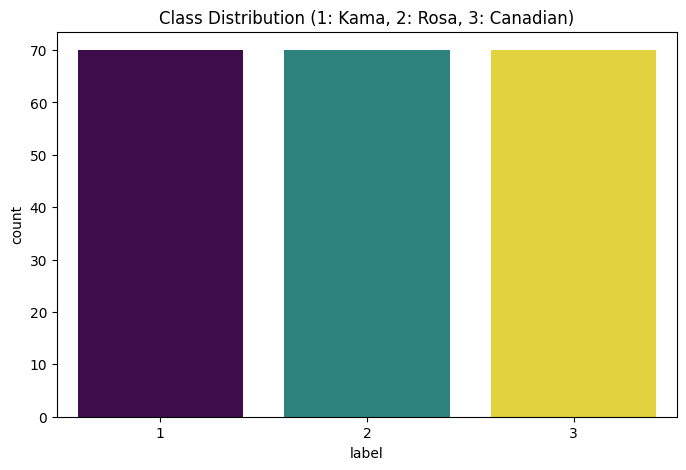

In [21]:
#  Class distribution
class_counts = df['label'].value_counts()
print("\nSamples per wheat variety:\n", class_counts)

plt.figure(figsize=(8, 5))
# Fixing the deprecation: assign x to hue and set legend=False
sns.countplot(data=df, x='label', hue='label', palette='viridis', legend=False)
plt.title('Class Distribution (1: Kama, 2: Rosa, 3: Canadian)')
plt.savefig('task5_countplot.png')

##### There are exactly **70 samples** for each label. This balance is ideal for training classification models as it prevents the model from developing a bias toward a majority class.

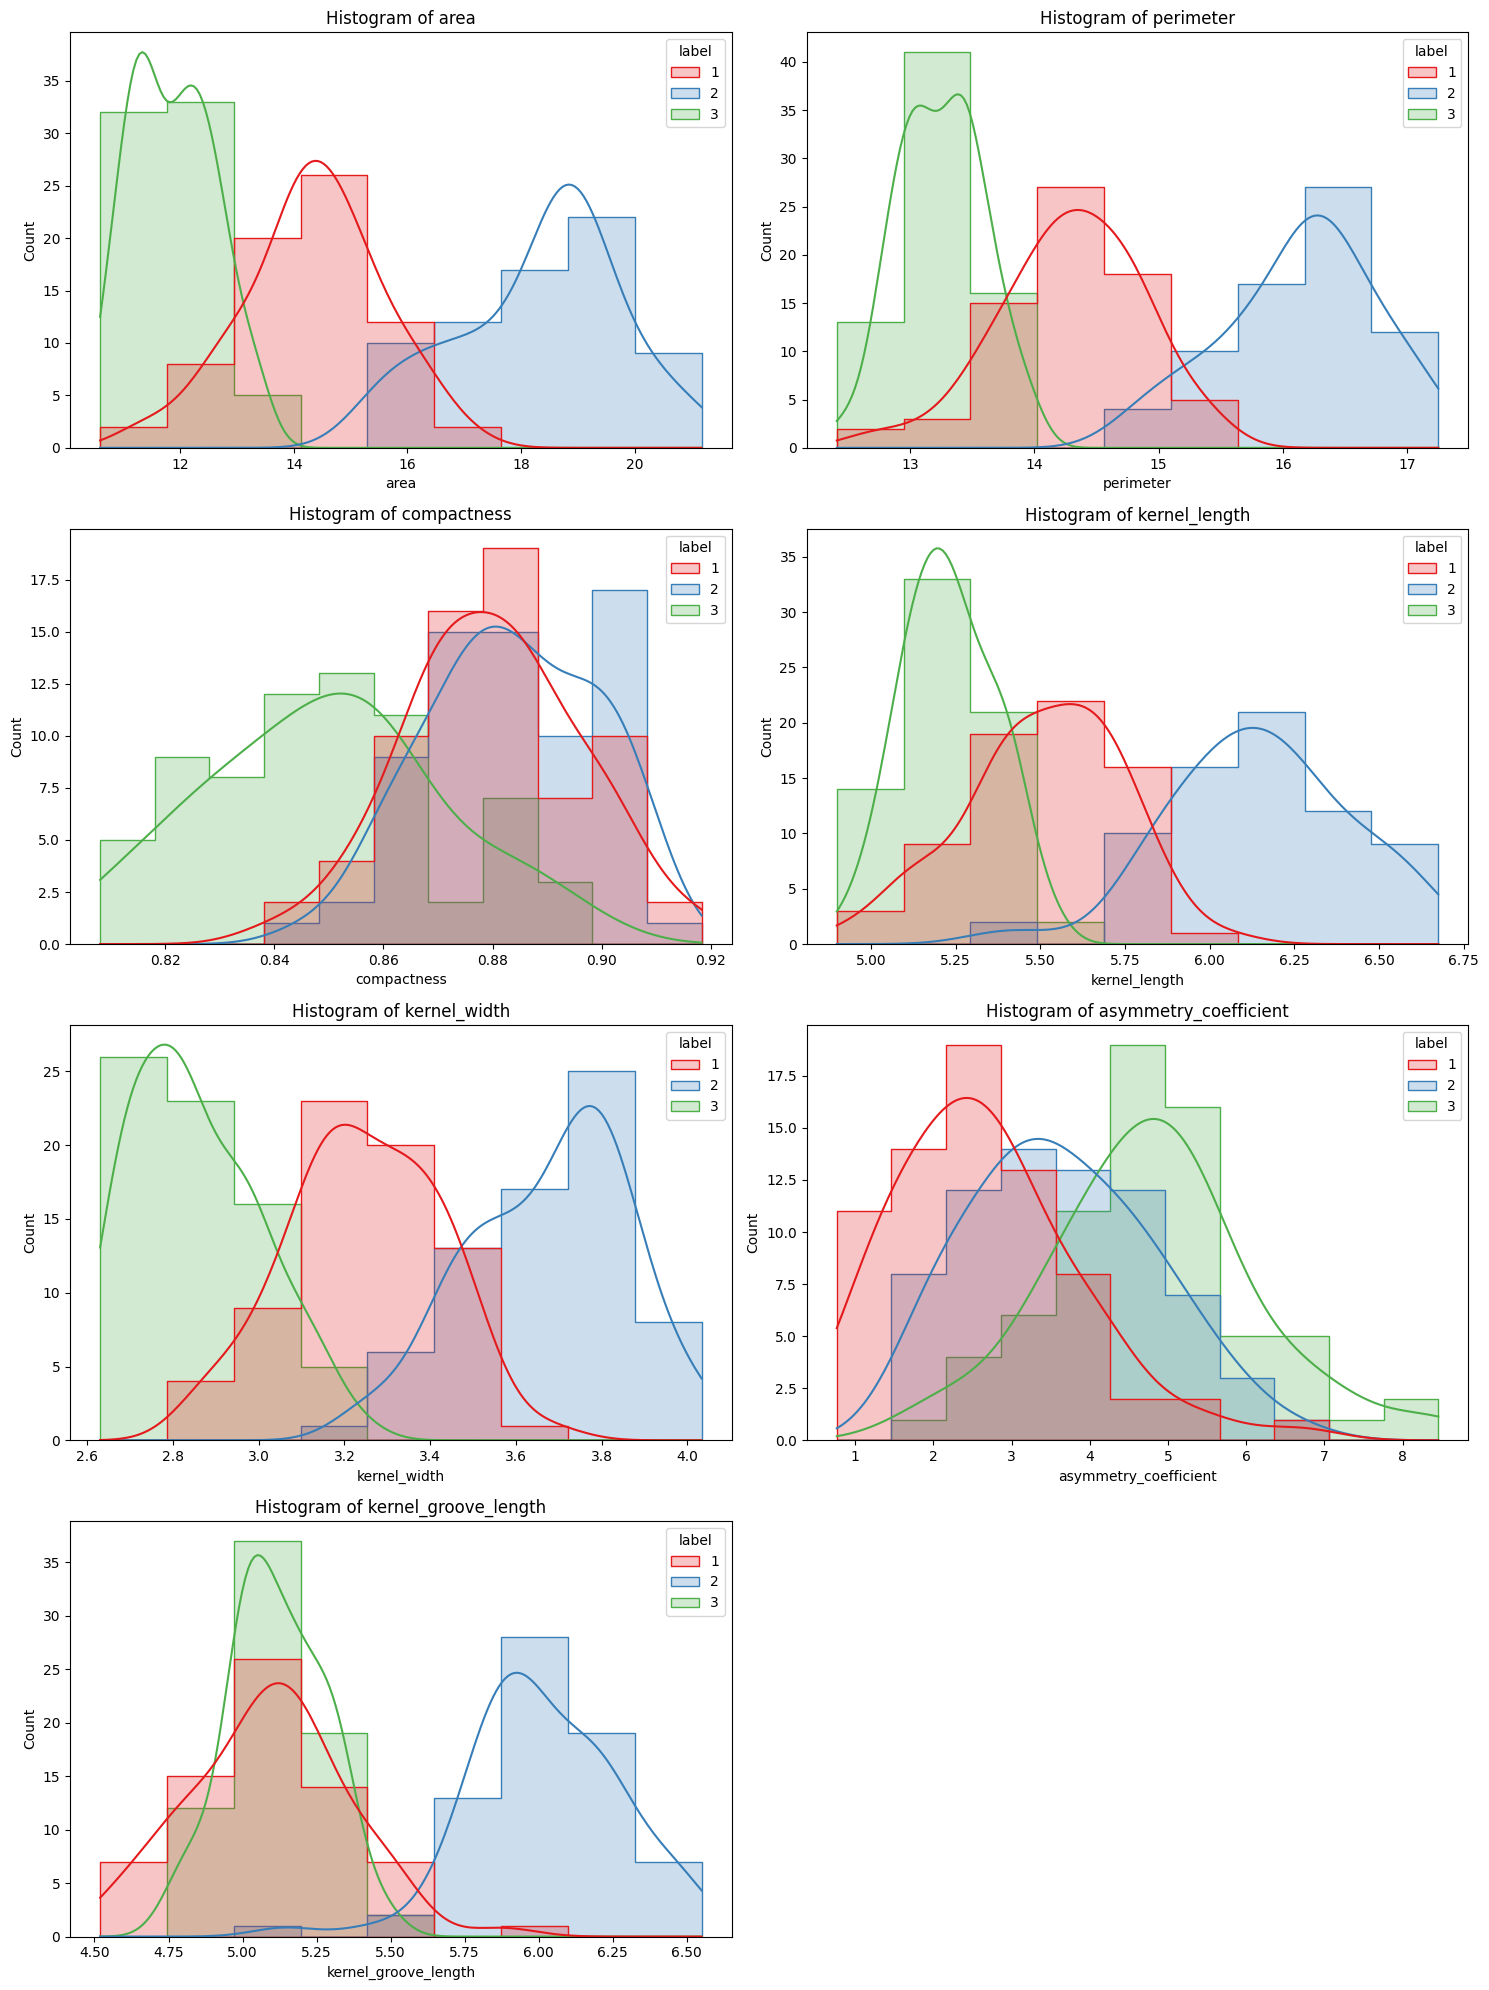

In [22]:
#  Histograms for  7 features
features = cols[:-1]
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df, x=col, hue='label', kde=True, ax=axes[i], palette='Set1', element='step')
    axes[i].set_title(f'Histogram of {col}')

# Remove the empty 8th subplot
fig.delaxes(axes[7])
plt.tight_layout()
plt.savefig('feature_histograms.png')

##### Features like **Area**, **Perimeter**, and **Kernel Length** show a clear rightward shift for label 2, making it easily distinguishable. Labels 1 and 3 show more overlap, particularly in Compactness and Kernel Width.

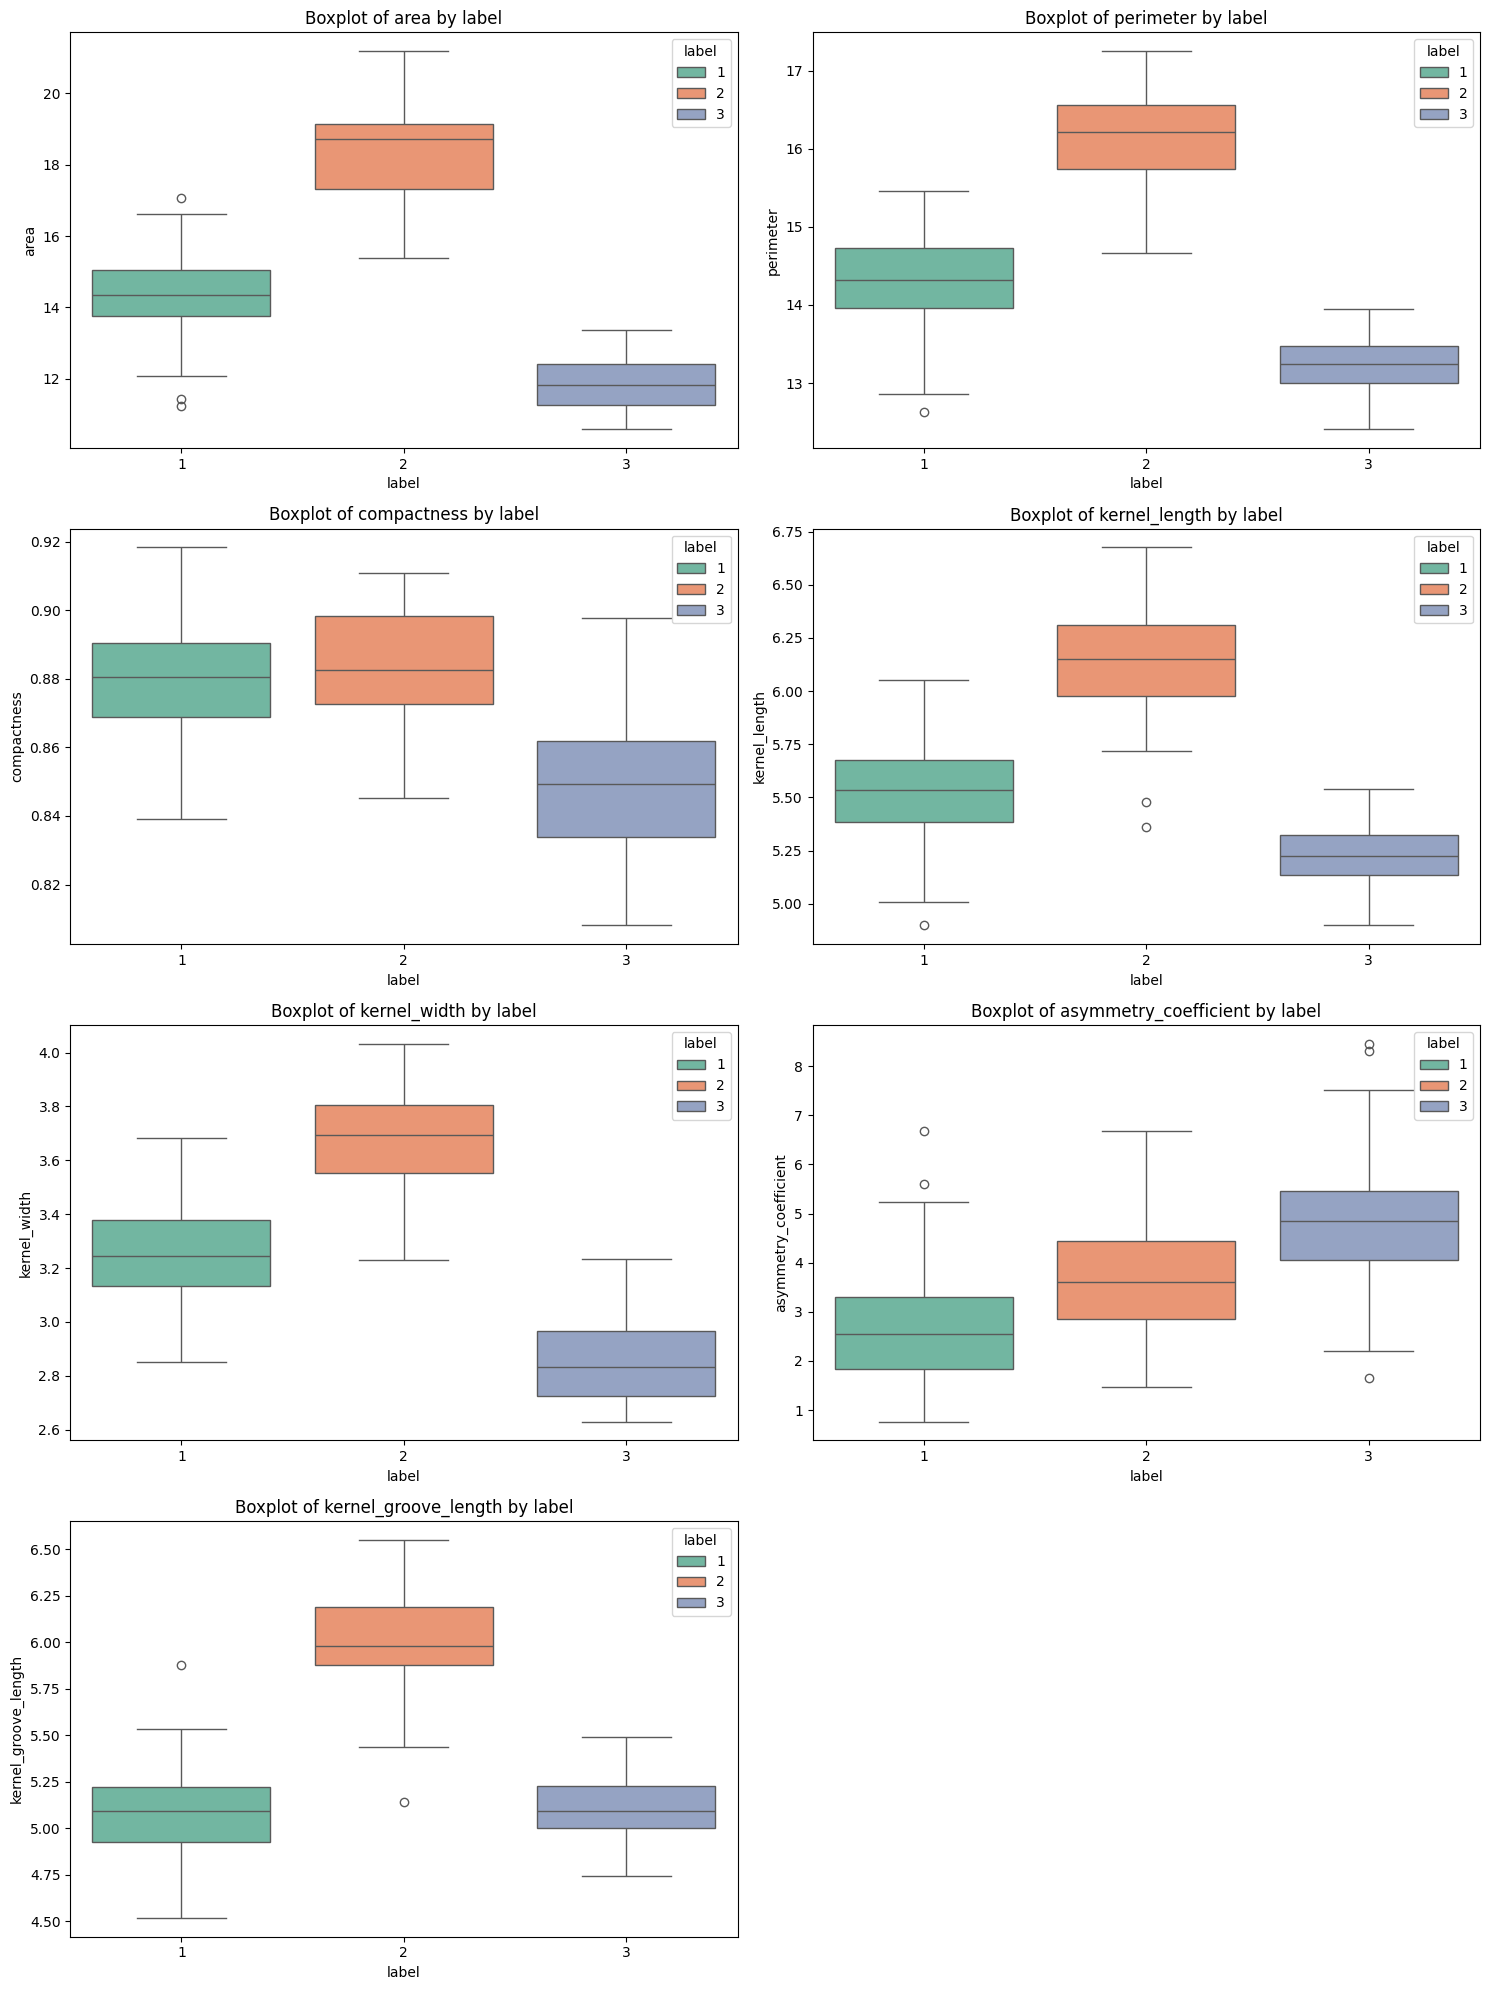

In [28]:
# Boxplots for features grouped by class

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='label', y=col, hue='label', palette='Set2', ax=axes[i])
    axes[i].set_title(f'Boxplot of {col} by label')

fig.delaxes(axes[7])
plt.tight_layout()
plt.savefig('feature_boxplots.png')

##### The boxplots highlight that label 2 generally has larger dimensions across most features. Label 3 shows several outliers in the Asymmetry Coefficient and Compactness features.

In [31]:

#  Outlier Detection
outlier_details = []
for feature in features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    if not outliers.empty:
        for idx in outliers.index:
            outlier_details.append({'Row': idx, 'Feature': feature, 'Value': df.loc[idx, feature]})

outlier_df = pd.DataFrame(outlier_details)
print("\nOutliers detected based on IQR method:")
print(outlier_df)


Outliers detected based on IQR method:
   Row                Feature   Value
0  157            compactness  0.8081
1  158            compactness  0.8082
2  174            compactness  0.8099
3  203  asymmetry_coefficient  8.4560
4  207  asymmetry_coefficient  8.3150


##### **Findings:** Outliers were documented primarily in Compactness (Rows 157, 158, 174) and Asymmetry Coefficient (Rows 203, 207).

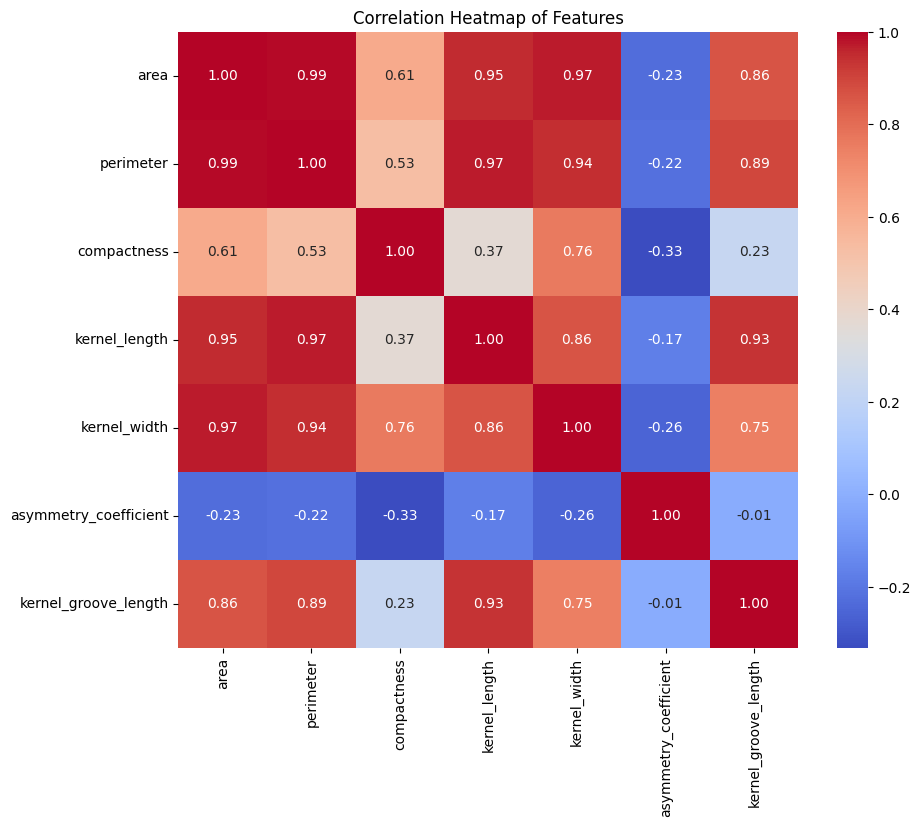

In [32]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, :-1].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.savefig('correlation_heatmap.png')

##### There is a near-perfect correlation **($\approx 0.99$)** between **Area** and **Perimeter**, as well as **Kernel Length** and **Kernel Width**. This indicates significant redundancy among size-related features. **Asymmetry Coefficient** shows the lowest correlation with other features, suggesting it provides unique shape-related information. 

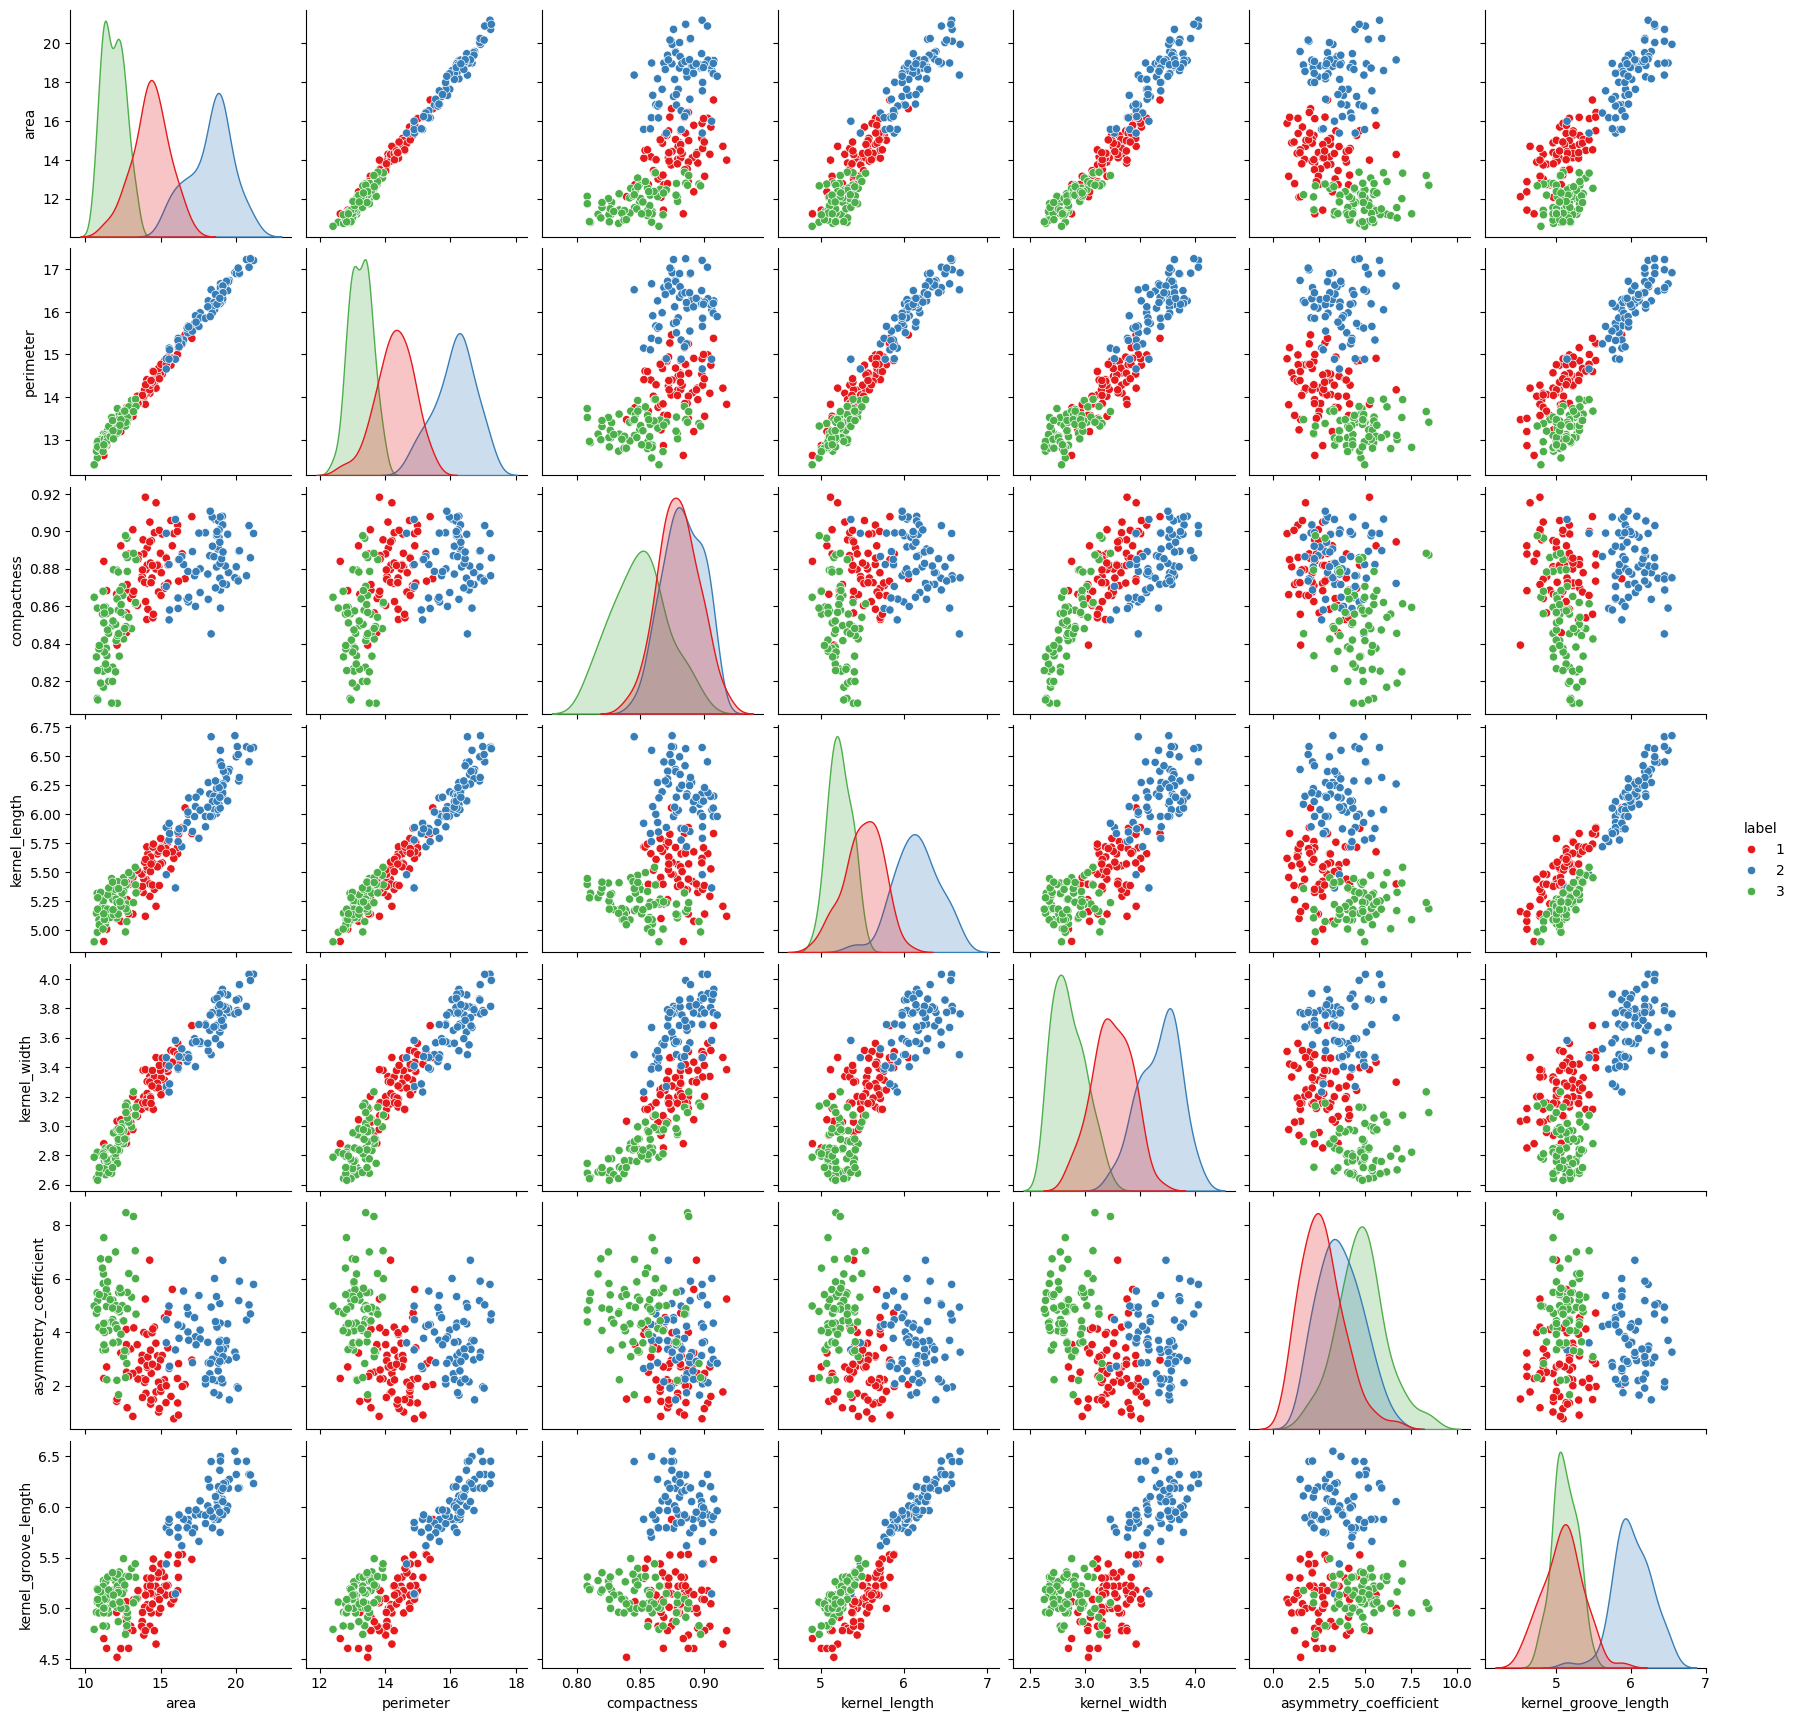

In [ ]:
# Pairplot
pairplot_fig = sns.pairplot(df, hue='label', palette='Set1', diag_kind='kde')
pairplot_fig.savefig('pairplot.png')

##### The pairplot confirms that label 2 is linearly separable from the other two based on almost any size-related feature. Labels 1 and 3 are more tightly clustered together but show separation when comparing **Kernel Groove Length** against **Area**.

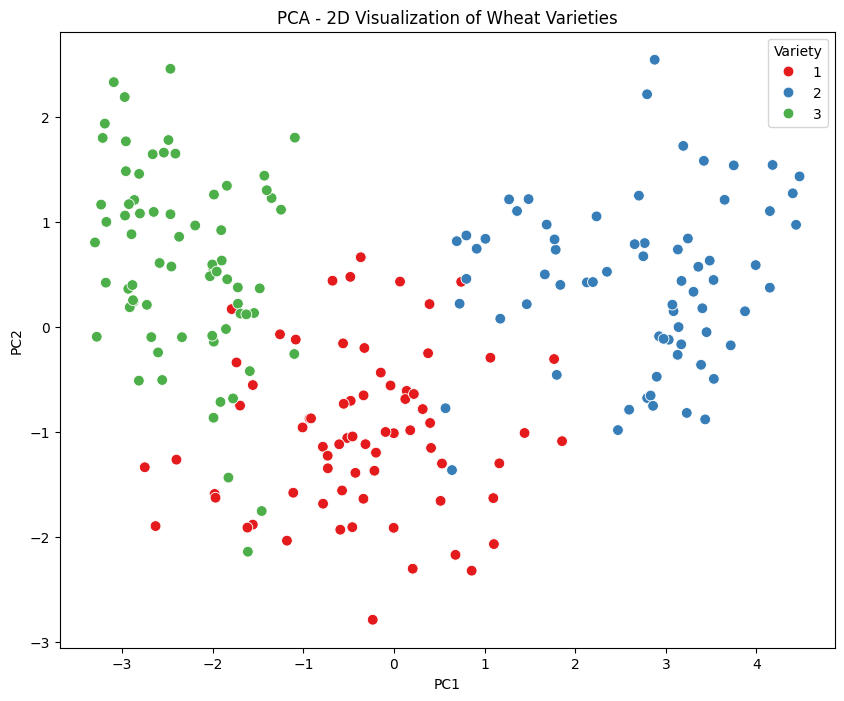

In [39]:
#  PCA
desc_overall = df.describe()
desc_per_class = df.groupby('label').describe()
features = df.drop('label', axis=1)
labels = df['label']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['Variety'] = labels.values

plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Variety', palette='Set1', s=60)
plt.title('PCA - 2D Visualization of Wheat Varieties')
plt.savefig('pca_scatter.png')

# Save descriptive stats to CSV for user
desc_overall.to_csv('descriptive_stats_overall.csv')
# Flatten multi-index for per-class stats to save to CSV
desc_per_class_flat = desc_per_class.T.reset_index()
desc_per_class_flat.to_csv('descriptive_stats_per_class.csv')
if not outlier_df.empty:
    outlier_df.to_csv('outliers_documented.csv')

##### **Interpretation:** The PCA plot demonstrates that the classes are visually separable. Label 2 forms a completely isolated cluster on the left. Labels 1 and 3 form two distinct clusters on the right with very minimal overlap. This high level of separation in 2D space suggests that even simple linear classification models should perform exceptionally well on this dataset.